In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# DADES (exemple)
# -----------------------------
RT = 0.1            # transmissibilitat objectiu
f = 100             # Hz (freq excitació)
omega = 2*np.pi*f

m = 3000             # kg (massa total ja calculada)
EA = 16e6            # N (E*A aproximat)

In [3]:
# -----------------------------
# DISSENY (segons el teu desenvolupament)
# -----------------------------
Omega2 = 1/RT + 1
Omega = np.sqrt(Omega2)

omega_n = omega / Omega

k = m * omega_n**2
h = EA / (k)        # equivalent a EA / (omega_n^2 * m)

print('\n'+ '-'*40)
print(f"omega_n : {omega_n:.1f} rad/s")
print(f"k       : {k:.2e} N/m")
print(f"h       : {h:.3f} m")
print('-'*40 + '\n')


----------------------------------------
omega_n : 189.4 rad/s
k       : 1.08e+08 N/m
h       : 0.149 m
----------------------------------------



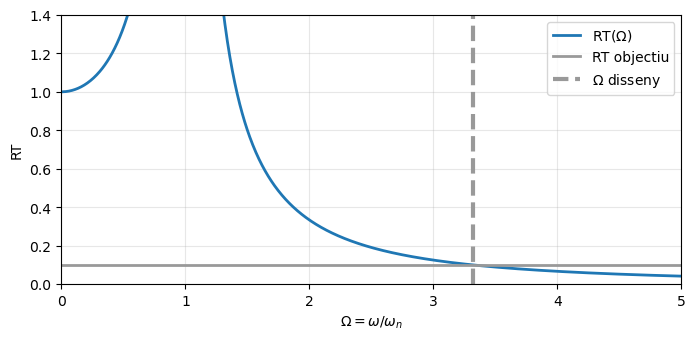

In [4]:
# -----------------------------
# TRANSMISSIBILITAT
# -----------------------------
zeta = 0.02   # petit amortiment

Omega_vec = np.linspace(0.01, 5, 1000)

RT_vec = np.sqrt(1 + (2*zeta*Omega_vec)**2) / \
         np.sqrt((1 - Omega_vec**2)**2 + (2*zeta*Omega_vec)**2)
# -----------------------------
# PLOT TRANSMISSIBILITAT
# -----------------------------
plt.figure(figsize=(8,3.5))
plt.plot(Omega_vec, RT_vec, linewidth=2,  label=r'RT$(\Omega)$')
plt.axhline(RT, color='0.6',  linewidth=2,  label='RT objectiu')
plt.axvline(Omega, color='0.6', linestyle='--', linewidth=3, label=r'$\Omega$ disseny')
plt.xlabel(r'$\Omega = \omega / \omega_n$')
plt.ylabel('RT')
plt.xlim([0, 5])
plt.ylim([0, 1.4])
plt.grid(True, alpha=0.3)
plt.legend()

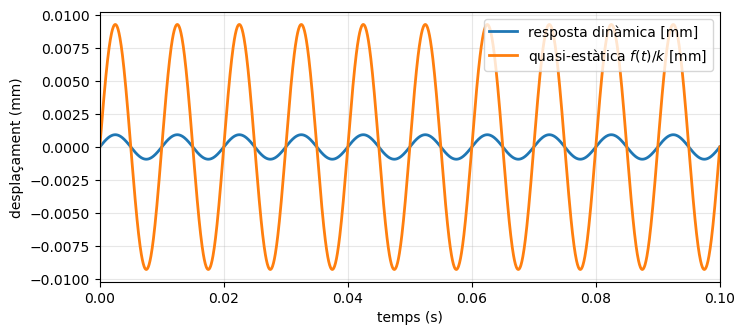

In [5]:
# -----------------------------
# RESPOSTA TEMPORAL
# -----------------------------
t = np.linspace(0, 0.1, 2000)
F0 = 1000

x = (F0/k) * np.sin(omega*t) / np.sqrt((1 - (omega/omega_n)**2)**2 + (2*zeta*(omega/omega_n))**2)

plt.figure(figsize=(8,3.5))
plt.plot(t, x*1e3, linewidth=2, label='resposta dinàmica [mm]')
plt.plot(t, (F0/k)*np.sin(omega*t)*1e3, linewidth=2, label=r'quasi-estàtica $f(t)/k$ [mm]')
plt.xlim([0, 0.1])

plt.xlabel('temps (s)')
plt.ylabel('desplaçament (mm)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()